# Demo on mobility-CIR-CFR

- This code demonstrates how channel frequency response (CFR) and channel impulse response (CIR) changes as the transceivers move.
- The captured CFR and CIR can be animated.

In [1]:
import sionna.rt

import time
import os
import re

import cv2
from PIL import Image

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial, SceneObject

import scipy.signal
import scipy.linalg

jitc_llvm_init(): LLVM API initialization failed ..


In [2]:
# scene = load_scene("../assets/ssm-scene/ssm-scene-v2_3.xml")
scene = load_scene(sionna.rt.scene.simple_street_canyon_with_cars, merge_shapes=False)

scene.frequency = 5e9

scene.tx_array = PlanarArray(num_rows=2,
                             num_cols=2,  # Reduced from 4x4 to allow longer CFR observation window
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=4,
                             num_cols=4,  # Reduced from 8x8 to allow longer CFR observation window
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="VH")
# scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
# scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
try:
    scene.synthetic_array = True
except Exception:
    pass

# # Create transmitters.
# tx1 = Transmitter(name="tx1", # Node 24.
#                   # position=[3,-57,0.75],
#                   position=[0,0,0.75],
#                   velocity=[0, 10, 0])

# rx1 = Receiver(name="rx1", # BS position 4.
#                # position=[-5, -13, 20],
#                position=[0, 0, 20],
#                look_at=[0, 0, 0])

bs_pos = [-25.0, 0.0, 15.0]
tx = Transmitter(name="bs", position=bs_pos)
scene.add(tx)
# car_2 mesh는 그대로 두고 (장애물/반사체 역할)
car_2 = scene.get("car_2")
car_2.position += [0, 20, 0]
car_2.orientation = [np.pi/2, 0, 0]

# UE(안테나)는 별도 이름으로 생성, car_2 위치를 따라가도록 설정
# position에는 tensor가 아니라 plain list를 넣어주는 게 안전합니다
car_2_pos = car_2.position.numpy()[:, 0]          # [x, y, z]
ue_pos = car_2_pos + [0, 0, 1.0]                    # 차 지붕 위 1m에 안테나 마운트
ue_start_pos = ue_pos.copy()  # 시뮬레이션 시작 시점의 UE 위치

velocity=np.array([0, -10, 0])
rx = Receiver(name="ue", position=ue_pos.tolist(), orientation=car_2.orientation)

scene.add(rx)

scene.preview();


In [3]:
# 15 kHz subcarrier spacing.
# 264 subcarriers (Half of NR standards).
# 14 OFDM symbols per slot.
subcarrier_spacing = 15e3
num_subcarriers = 264
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)
num_ofdm_symbols = 14
num_paths = 5 # Desired number of paths of CIR reconstruction.

bandwidth = num_subcarriers * subcarrier_spacing
print(f"Total bandwidth: {bandwidth / 1e6} MHz")
print(f"Time resolution: {1e6/bandwidth:.3f} us")

p_solver = PathSolver()

Total bandwidth: 3.96 MHz
Time resolution: 0.253 us


In [4]:
paths = p_solver(scene=scene,
                 max_depth=1,
                 los=True,
                 specular_reflection=False,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=True,
                 seed=1)

## Generate CFR-CIR output for slowly moving transceivers.

In [5]:
from operator import pos


    
num_time_steps = 20
velocity=np.array([0, -10, 0])
time_step_length = 0.1
car_2_traj_x = np.linspace(car_2_pos[0], car_2_pos[0] + 0, num_time_steps)
car_2_traj_y = np.linspace(car_2_pos[1], car_2_pos[1] - 20, num_time_steps)
car_2_traj_z = np.linspace(car_2_pos[2], car_2_pos[2] + 0, num_time_steps)
car_2_traj = np.stack([car_2_traj_x, car_2_traj_y, car_2_traj_z], axis=1)


# for t in range(num_time_steps):
#     scene.get("tx1").position += [0.1, 0, 0]
#     print(scene.get("tx1").position)
#     paths = p_solver(scene=scene,
#                  max_depth=5,
#                  los=False,
#                  specular_reflection=True,

for t in range(num_time_steps):
    # Update position
    car_2_pos = np.asarray(scene.get("car_2").position, dtype=float).flatten()
    scene.get("car_2").position = (car_2_pos + time_step_length * velocity).tolist()
    scene.get("car_2").velocity = velocity.tolist()

    # keep the UE update consistent with NumPy arrays (avoid list * float)
    ue_pos = time_step_length * velocity + np.array([0.0, 0.0, 1.0], dtype=float)
    scene.get("car_2").velocity = velocity.tolist()
    ue_pos = time_step_length*velocity + np.array([0, 0, 1.0])
    scene.get("ue").position = ue_pos.tolist()
    scene.get("ue").velocity = velocity.tolist()
    paths = p_solver(scene=scene, 
                    max_depth=1, 
                    los=True,
                    specular_reflection=False, 
                    diffuse_reflection=False,
                    refraction=True, 
                    diffraction=True,
                    synthetic_array=True,
                    seed=1)
    cfr = paths.cfr(frequencies=frequencies,
                    sampling_frequency=subcarrier_spacing,  # FIX: symbol rate (1/T_sym), not total bandwidth
                    num_time_steps=num_ofdm_symbols,
                    normalize_delays=False,
                    normalize=False,
                    out_type="numpy")

    cir = paths.cir(sampling_frequency=subcarrier_spacing,  # FIX: matches Sionna Mobility tutorial (symbol rate)
                    num_time_steps=num_ofdm_symbols,
                    normalize_delays=False,
                    out_type="numpy")
    cir_a = cir[0]
    cir_tau = cir[1]


    # Target Tx, Rx, antenna.
    target_rx = 0
    target_tx = 0
    target_rx_ant = 0
    target_tx_ant = 0
        
    target_cfr = cfr[target_rx, target_rx_ant, target_tx, target_tx_ant, :, :]
    
    cir_target_a = cir_a[target_rx, target_rx_ant, target_tx, target_tx_ant, :, :]

    if len(cir[1].shape) == 3:
        cir_target_tau = cir_tau[target_rx, target_tx, :]
    else:
        cir_target_tau = cir_tau[target_rx, target_rx_ant, target_tx, target_tx_ant, :]
    
    valid_indices = np.where(cir_target_tau >= 0)[0]
    clean_tau = cir_target_tau[valid_indices]
    num_valid_paths = len(clean_tau)
    cir_target_a = cir_target_a[valid_indices]
    cir_target_tau = cir_target_tau[valid_indices]
    cir_target_tau_us = cir_target_tau * 1e6
    
    # Square to calculate power.
    target_cir_power_avg = np.mean(np.abs(cir_target_a) ** 2, axis=1)

    # Calculate phase of time-averaged complex CIR for each valid path.
    cir_target_phase_deg = np.degrees(np.angle(np.mean(cir_target_a, axis=1)))

    num_cfr_time_steps = target_cfr.shape[0]  # actual num_time_steps used
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- axes[0]: Original CFR ---
    axes[0].set_title('Original CFR')
    im1 = axes[0].pcolormesh(np.abs(target_cfr.transpose()))
    axes[0].set_xlabel('Time (OFDM symbols)')
    axes[0].set_ylabel('Frequency (Subcarriers)')
    axes[0].set_xlim([0, num_cfr_time_steps])
    axes[0].set_xticks(range(0, num_cfr_time_steps + 1, max(1, num_cfr_time_steps // 7)))
    fig.colorbar(im1, ax=axes[0], label='Magnitude')

    # --- axes[1]: Average PDP (Linear) ---
    markerline, stemlines, baseline = axes[1].stem(cir_target_tau_us, target_cir_power_avg, basefmt=" ")
    plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 6)
    plt.setp(stemlines, 'color', 'k', 'linewidth', 1.5)
    axes[1].set_xlabel('Delay ($\\mu s$)')
    axes[1].set_ylabel('Average Power (Linear)')
    axes[1].set_title('Average Power Delay Profile (PDP)')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    # --- axes[2]: Average Phase vs. Delay (replaces PDP dB) ---
    markerline, stemlines, baseline = axes[2].stem(cir_target_tau_us, cir_target_phase_deg, basefmt=" ")
    plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 6)
    plt.setp(stemlines, 'color', 'k', 'linewidth', 1.5)
    axes[2].set_xlabel('Delay ($\\mu s$)')
    axes[2].set_ylabel('Phase (Degrees)')
    axes[2].set_title('Average Phase vs. Delay')
    axes[2].grid(True, linestyle='--', alpha=0.5)
    
    # plt.show()
    os.makedirs("demo_figs", exist_ok=True)
    plt.savefig(f"demo_figs/h-{t}.png")
    plt.close()
    


In [6]:
def img2vid(img_dir, time_slot_length, header="snapshot"):
    """
    Change set of png images to an mp4 video.
    The directory should contain images labeled in integers (1, 2, ...).
    """
    video_name = os.path.join(img_dir, f"video-{header}.mp4")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    images = [img for img in os.listdir(img_dir) if img.endswith('png')]

    # Classify according to header.
    images = [img for img in images if img.startswith(header)]

    # Sort.
    # sorted_images = sorted(images, key=lambda fn: int(fn.split('.', 1)[0]))
    def get_number_from_filename(filename):
        match = re.search(fr'{header}-(\d+)\.png', filename)
        if match:
            return int(match.group(1))
        return 0 # Default value if pattern doesn't match.
    images.sort(key=get_number_from_filename)

    frame = cv2.imread(os.path.join(img_dir, images[0]))

    height, width, layers = frame.shape
    video = cv2.VideoWriter(filename=video_name, fourcc=fourcc, fps=1/time_slot_length, frameSize=(width,height))
    for image in images:
        print(image)
        video.write(cv2.imread(os.path.join(img_dir, image)))

    cv2.destroyAllWindows()
    video.release()

img2vid("demo_figs", 0.5, "h")

h-0.png
h-1.png
h-2.png
h-3.png
h-4.png
h-5.png
h-6.png
h-7.png
h-8.png
h-9.png
h-10.png
h-11.png
h-12.png
h-13.png
h-14.png
h-15.png
h-16.png
h-17.png
h-18.png
h-19.png


## Generate UL CIR-DL CIR for slowly moving transceivers.

In [7]:
# Helper function to process CIR data for a specific link.
def get_pdp_data(cir_tuple, rx_idx=0, rx_ant_idx=0, tx_idx=0, tx_ant_idx=0):
    """
    Extracts delays and computes Average Power Delay Profile (PDP) from Sionna CIR output.
    """
    a, tau = cir_tuple
    
    # Sionna Output Shapes (Standard):
    # a: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    # tau: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
    
    # Extract specific link data.
    # Squeezing batch dimension (index 0).
    # Shape becomes: [num_paths, num_time_steps] for 'a' and [num_paths] for 'tau'.
    link_a = a[rx_idx, rx_ant_idx, tx_idx, tx_ant_idx, :, :]
    
    if len(tau.shape) == 3:
        link_tau = tau[rx_idx, tx_idx, :]
    else:
        link_tau = tau[rx_idx, rx_ant_idx, tx_idx, tx_ant_idx, :]

    # Filter invalid paths (Sionna pads with -1).
    valid_mask = link_tau >= 0
    clean_tau = link_tau[valid_mask]
    clean_a = link_a[valid_mask, :]

    # Convert delay to microseconds.
    tau_us = clean_tau * 1e6

    # Calculate Power (Linear).
    # Average the instantaneous power (|h|^2) over the time steps (OFDM symbols).
    pdp_linear = np.mean(np.abs(clean_a)**2, axis=1)

    # Calculate Power (dB).
    # 10*log10(Power). Add epsilon to avoid log(0).
    pdp_db = 10 * np.log10(pdp_linear + 1e-16)

    return tau_us, pdp_linear, pdp_db


In [8]:
num_time_steps = 20

# car_2 moves [0, -20, 0] over time.
car_2_traj_x = np.linspace(car_2_pos[0], car_2_pos[0] + 0, num_time_steps)
car_2_traj_y = np.linspace(car_2_pos[1], car_2_pos[1] - 20, num_time_steps)
car_2_traj_z = np.linspace(car_2_pos[2], car_2_pos[2] + 0, num_time_steps)
car_2_traj = np.stack([car_2_traj_x, car_2_traj_y, car_2_traj_z], axis=1)


for t in range(num_time_steps):
    # Update position
    scene.get("car_2").position = car_2_traj[t].tolist()
    ue_pos = car_2_traj[t] + [0, 0, 1.0]
    scene.get("ue").position = ue_pos.tolist()

    # Run Path Solver
    paths = p_solver(scene=scene, 
                    max_depth=1, 
                    los=True,
                    specular_reflection=False, 
                    diffuse_reflection=False,
                    refraction=True, 
                    diffraction=True,
                    synthetic_array=True,
                    seed=1)

    # Generate CIR for Uplink and Downlink
    ul_cir = paths.cir(sampling_frequency=subcarrier_spacing,  # FIX: symbol rate (1/T_sym), not total bandwidth
                       num_time_steps=num_ofdm_symbols,
                       normalize_delays=False,
                       out_type="numpy")
    
    dl_cir = paths.cir(sampling_frequency=subcarrier_spacing,  # FIX: symbol rate (1/T_sym), not total bandwidth
                       num_time_steps=num_ofdm_symbols,
                       normalize_delays=False,
                       out_type="numpy",
                       reverse_direction=True)


    ul_tau, ul_pwr_lin, ul_pwr_db = get_pdp_data(ul_cir)
    dl_tau, dl_pwr_lin, dl_pwr_db = get_pdp_data(dl_cir)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Channel Impulse Response (CIR) - Step {t}", fontsize=16)

    markerline, stemlines, baseline = axes[0, 0].stem(ul_tau, ul_pwr_db, basefmt=" ")
    plt.setp(markerline, 'markerfacecolor', 'b', 'markersize', 6)
    plt.setp(stemlines, 'color', 'b', 'linewidth', 1.5)
    axes[0, 0].set_title("Uplink CIR (dB)")
    axes[0, 0].set_ylabel("Power (dB)")
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)

    markerline, stemlines, baseline = axes[0, 1].stem(ul_tau, ul_pwr_lin, basefmt=" ")
    plt.setp(markerline, 'markerfacecolor', 'b', 'markersize', 6)
    plt.setp(stemlines, 'color', 'b', 'linewidth', 1.5)
    axes[0, 1].set_title("Uplink CIR (Linear)")
    axes[0, 1].set_ylabel("Power (Linear)")
    axes[0, 1].grid(True, linestyle='--', alpha=0.5)

    markerline, stemlines, baseline = axes[1, 0].stem(dl_tau, dl_pwr_db, basefmt=" ")
    plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 6)
    plt.setp(stemlines, 'color', 'r', 'linewidth', 1.5)
    axes[1, 0].set_title("Downlink CIR (dB)")
    axes[1, 0].set_ylabel("Power (dB)")
    axes[1, 0].set_xlabel(r"Delay ($\mu s$)")
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)

    markerline, stemlines, baseline = axes[1, 1].stem(dl_tau, dl_pwr_lin, basefmt=" ")
    plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 6)
    plt.setp(stemlines, 'color', 'r', 'linewidth', 1.5)
    axes[1, 1].set_title("Downlink CIR (Linear)")
    axes[1, 1].set_ylabel("Power (Linear)")
    axes[1, 1].set_xlabel(r"Delay ($\mu s$)")
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    
    os.makedirs("demo_figs2", exist_ok=True) 
    plt.savefig(f"demo_figs2/h-{t}.png")
    plt.close()

print("Complete.")


Complete.


In [9]:
def img2vid(img_dir, time_slot_length, header="snapshot"):
    """
    Change set of png images to an mp4 video.
    The directory should contain images labeled in integers (1, 2, ...).
    """
    video_name = os.path.join(img_dir, f"video-{header}.mp4")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    images = [img for img in os.listdir(img_dir) if img.endswith('png')]

    # Classify according to header.
    images = [img for img in images if img.startswith(header)]

    # Sort.
    # sorted_images = sorted(images, key=lambda fn: int(fn.split('.', 1)[0]))
    def get_number_from_filename(filename):
        match = re.search(fr'{header}-(\d+)\.png', filename)
        if match:
            return int(match.group(1))
        return 0 # Default value if pattern doesn't match.
    images.sort(key=get_number_from_filename)

    frame = cv2.imread(os.path.join(img_dir, images[0]))

    height, width, layers = frame.shape
    video = cv2.VideoWriter(filename=video_name, fourcc=fourcc, fps=1/time_slot_length, frameSize=(width,height))
    for image in images:
        print(image)
        video.write(cv2.imread(os.path.join(img_dir, image)))

    cv2.destroyAllWindows()
    video.release()

img2vid("demo_figs2", 0.5, "h")

h-0.png
h-1.png
h-2.png
h-3.png
h-4.png
h-5.png
h-6.png
h-7.png
h-8.png
h-9.png
h-10.png
h-11.png
h-12.png
h-13.png
h-14.png
h-15.png
h-16.png
h-17.png
h-18.png
h-19.png


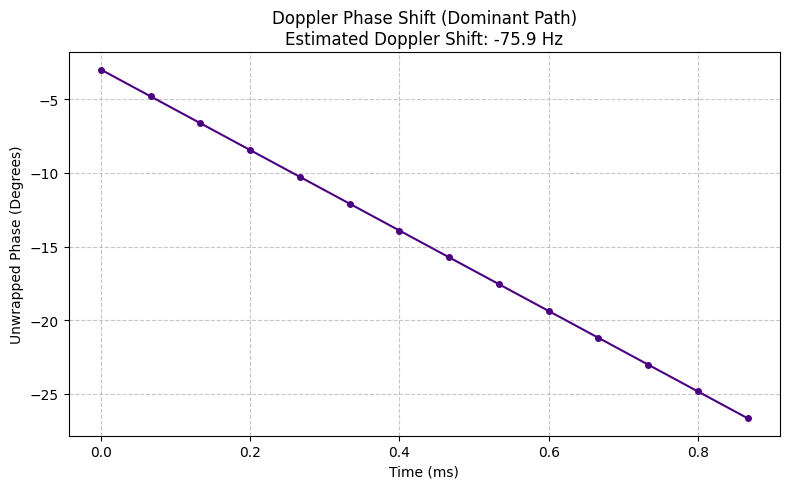

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 가정: p_solver, scene, num_time_steps 등이 이미 정의되어 있고,
# 앞선 프롬프트 적용으로 rx(단말) 객체에 velocity가 할당되어 있음.
# 관찰 시간을 늘리기 위해 num_time_steps = 140 (약 10ms) 등으로 설정 권장.
# -------------------------------------------------------------------

def plot_doppler_phase(cir_tuple, num_time_steps, scs=15e3):
    """
    CIR 데이터에서 Dominant Path의 시간에 따른 위상 변화를 그립니다.
    """
    a, tau = cir_tuple
    
    # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    # 특정 링크(rx=0, tx=0, ant=0)의 복소 경로 이득 추출
    link_a = a[0, 0, 0, 0, :, :] # 형태: [num_paths, num_time_steps]
    
    # tau 데이터 추출 (유효한 경로 마스킹용)
    if len(tau.shape) == 3:
        link_tau = tau[0, 0, :]
    else:
        link_tau = tau[0, 0, 0, 0, :]
        
    valid_mask = link_tau >= 0
    clean_a = link_a[valid_mask, :] # 형태: [valid_paths, num_time_steps]
    
    if clean_a.shape[0] == 0:
        print("유효한 경로가 없습니다.")
        return

    # 시간 축 계산 (OFDM 심볼 단위의 대략적인 시간 간격)
    # 15kHz SCS의 경우 1 심볼 길이는 대략 1/15000 초 (CP 제외 기준 근사치)
    symbol_duration = 1 / scs
    time_axis_ms = np.arange(num_time_steps) * symbol_duration * 1000

    # 1. 가장 강한 경로(Dominant Path) 찾기 (시간 평균 전력이 가장 높은 경로)
    path_power = np.mean(np.abs(clean_a)**2, axis=1)
    dominant_path_idx = np.argmax(path_power)
    
    # 2. Dominant Path의 시간에 따른 복소수 이득 추출
    dominant_a_over_time = clean_a[dominant_path_idx, :]
    
    # 3. 위상(Phase) 계산 및 Unwrapping
    # np.angle은 -pi ~ pi 사이의 값을 반환하므로, 연속적인 위상 변화를 보기 위해 unwrap 적용
    phase_rad = np.unwrap(np.angle(dominant_a_over_time))
    phase_deg = np.degrees(phase_rad)
    
    # 4. 도플러 주파수 근사치 계산 (위상의 기울기 기반)
    # 위상 변화율(rad/s) = 2 * pi * f_D
    phase_slope = np.polyfit(time_axis_ms / 1000, phase_rad, 1)[0]
    estimated_doppler = phase_slope / (2 * np.pi)

    # 5. 시각화
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(time_axis_ms, phase_deg, marker='o', linestyle='-', color='indigo', markersize=4)
    ax.set_title(f"Doppler Phase Shift (Dominant Path)\nEstimated Doppler Shift: {estimated_doppler:.1f} Hz")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Unwrapped Phase (Degrees)")
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# 실행 예시: 
# ul_cir는 paths.cir(...) 로 생성된 객체
plot_doppler_phase(ul_cir, num_time_steps=num_ofdm_symbols , scs=15e3)


## Timestep vs $\Re\{h(f,t)\}$ Heatmap (Doppler- vs Position-based)

Sionna Mobility 튜토리얼의 "Comparison of Doppler- vs Position-based Time Evolution" 절에서는
`h_sim`(물체를 실제로 이동시키며 매 OFDM 심볼마다 path를 재계산)과 `h_dop`(한 번 계산한 path에
Doppler shift를 해석적으로 적용)을 비교하고, 이를 몇 개의 subcarrier/timestep을 골라 선 그래프로
비교했습니다.

**조건 1, 2에 대한 검토 결과**는 다음과 같습니다.

1. **튜토리얼과 완전히 동일한 수치(1024 subcarrier, 30 kHz SCS, 25 symbol)를 그대로 가져오는 것은
   이론적으로 큰 의미가 없습니다.** 그 값들은 튜토리얼에서 Delay-Doppler 스펙트럼을 보기 좋게
   그리기 위해 임의로 고른 예시 숫자일 뿐, 특별히 표준적이거나 물리적으로 필연적인 값이 아닙니다.
   반면 이 노트북은 이미 `num_subcarriers=264`, `subcarrier_spacing=15kHz`, `num_ofdm_symbols=14`로
   **NR 한 슬롯(0.5 slot)에 해당하는 자체적인 numerology**를 정의해 두었으므로, 굳이 튜토리얼의
   숫자로 덮어쓰기보다 **이 노트북에서 이미 쓰고 있는 설정을 그대로 유지**하는 것이 뒤의 CFR/CIR
   셀들과의 일관성 측면에서 더 타당합니다. 따라서 "동일한 timestep 설정"은 숫자 자체가 아니라,
   **"timestep 축 = OFDM 심볼 주기(symbol duration) 단위로 진행되는 fine-scale Doppler 축"이라는
   튜토리얼의 개념**을 그대로 가져오는 것으로 해석해 구현했습니다.

2. **더 중요한 문제를 하나 발견해서 함께 수정했습니다.** 기존 셀들에서 `paths.cfr()` /
   `paths.cir()` 호출 시 `sampling_frequency=num_subcarriers * subcarrier_spacing` (즉 전체
   대역폭)를 사용하고 있었는데, 이는 이론적으로 잘못된 값입니다. `sampling_frequency`는
   "연속된 time step(OFDM 심볼) 사이의 샘플링 속도", 즉 심볼 주기 $T_{sym}=1/\Delta f$의 역수인
   **subcarrier spacing 자체**여야 합니다 (Mobility 튜토리얼에서도
   `sampling_frequency=1/ofdm_symbol_duration = subcarrier_spacing`를 사용). 전체 대역폭을 쓰면
   Sionna는 timestep 간격을 실제보다 약 264배(`num_subcarriers`배) 더 짧게 인식해서, 동일한
   `velocity`에 대해 Doppler 위상 회전량을 심하게 과소평가하게 됩니다. 이번 절에서는 이 수정된
   값(`sampling_frequency=subcarrier_spacing`)을 사용했고, 위쪽의 기존 CFR/CIR 셀들도 함께
   고쳤습니다.

아래에서는
- **h_dop**: 한 번의 path 계산 + `Paths.doppler` 기반 해석적 시간 evolution (빠름, 근사)
- **h_sim**: 매 OFDM 심볼(fine timestep)마다 `car_2`/`ue`를 물리적으로 조금씩 이동시키고
  path를 다시 트레이싱 (느림, 더 정확)

두 방식으로 얻은 $h(f,t)$의 실수부(real value)를 각각 (timestep × subcarrier) heatmap으로
그리고, 두 결과가 서로 잘 일치하는지 비교합니다.


In [11]:
# ------------------------------------------------------------
# Fine-scale (OFDM-symbol level) mobility setup for Doppler validation.
# 이 절은 위쪽 outer-loop(cell 10)의 실행 상태와 무관하게 동작하도록,
# "현재 scene에 있는 car_2/ue 위치"를 기준(baseline)으로 삼아 그 주변에서만
# 짧게(수 파장 이내) 움직이며 h(f,t)의 fine time evolution을 검증합니다.
# ------------------------------------------------------------

# 현재 scene 상태를 baseline으로 캡처
base_car2_pos = np.asarray(scene.get("car_2").position, dtype=float).flatten()
base_ue_pos = np.asarray(scene.get("ue").position, dtype=float).flatten()

# car_2(=UE가 탑재된 차량)의 속도. 노트북 앞부분에서 쓰던 것과 동일하게 유지.
fine_velocity = np.array([0.0, -10.0, 0.0])  # m/s

# Mobility 튜토리얼과 동일한 "timestep = OFDM 심볼 주기" 정의.
# (숫자는 튜토리얼의 1024/30kHz/25대신, 이 노트북의 264/15kHz/14 numerology를 그대로 사용)
ofdm_symbol_duration = 1 / subcarrier_spacing          # [s] per fine timestep
fine_displacement = fine_velocity * ofdm_symbol_duration  # 한 fine timestep당 이동량 [m]

print(f"OFDM symbol duration : {ofdm_symbol_duration*1e6:.3f} us")
print(f"Displacement / symbol: {np.linalg.norm(fine_displacement)*1e3:.4f} mm "
      f"(총 {num_ofdm_symbols}개 심볼 동안 {np.linalg.norm(fine_displacement)*num_ofdm_symbols*1e3:.2f} mm 이동)")

# 공통 PathSolver 설정 (노트북 상단의 다른 셀들과 동일한 설정 사용)
path_solver_kwargs = dict(
    max_depth=1,
    los=True,
    specular_reflection=False,
    diffuse_reflection=False,
    refraction=True,
    diffraction=True,
    synthetic_array=True,
    seed=1,
)

target_rx, target_rx_ant = 0, 0
target_tx, target_tx_ant = 0, 0


OFDM symbol duration : 66.667 us
Displacement / symbol: 0.6667 mm (총 14개 심볼 동안 9.33 mm 이동)


In [12]:
# ------------------------------------------------------------
# h_dop: 한 번의 path 계산 + Doppler shift 기반 해석적 시간 evolution
# ------------------------------------------------------------
scene.get("car_2").position = base_car2_pos.tolist()
scene.get("ue").position = base_ue_pos.tolist()
scene.get("car_2").velocity = fine_velocity.tolist()
scene.get("ue").velocity = fine_velocity.tolist()

paths_dop = p_solver(scene=scene, **path_solver_kwargs)

h_dop = paths_dop.cfr(
    frequencies=frequencies,
    sampling_frequency=subcarrier_spacing,   # FIX: symbol rate, not total bandwidth
    num_time_steps=num_ofdm_symbols,
    normalize_delays=False,
    normalize=True,
    out_type="numpy",
)
h_dop = h_dop[target_rx, target_rx_ant, target_tx, target_tx_ant, :, :]  # (num_ofdm_symbols, num_subcarriers)

print("h_dop shape (timestep, subcarrier):", h_dop.shape)


h_dop shape (timestep, subcarrier): (14, 264)


In [13]:
# ------------------------------------------------------------
# h_sim: 매 fine timestep(OFDM 심볼)마다 car_2/ue를 물리적으로 이동시키고
# path를 다시 트레이싱 (Mobility 튜토리얼의 "정확하지만 느린" 방식)
# ------------------------------------------------------------
scene.get("car_2").position = base_car2_pos.tolist()
scene.get("ue").position = base_ue_pos.tolist()
scene.get("car_2").velocity = fine_velocity.tolist()
scene.get("ue").velocity = fine_velocity.tolist()

h_sim_list = []
for t in range(num_ofdm_symbols):
    paths_t = p_solver(scene=scene, **path_solver_kwargs)

    h_t = paths_t.cfr(
        frequencies=frequencies,
        sampling_frequency=subcarrier_spacing,  # FIX: symbol rate, not total bandwidth
        num_time_steps=1,
        normalize_delays=False,
        normalize=True,
        out_type="numpy",
    )
    h_t = h_t[target_rx, target_rx_ant, target_tx, target_tx_ant, 0, :]  # (num_subcarriers,)
    h_sim_list.append(h_t)

    # 다음 fine timestep을 위해 물리적으로 조금 이동
    car2_pos_t = np.asarray(scene.get("car_2").position, dtype=float).flatten()
    scene.get("car_2").position = (car2_pos_t + fine_displacement).tolist()
    ue_pos_t = np.asarray(scene.get("ue").position, dtype=float).flatten()
    scene.get("ue").position = (ue_pos_t + fine_displacement).tolist()

h_sim = np.stack(h_sim_list, axis=0)  # (num_ofdm_symbols, num_subcarriers)

print("h_sim shape (timestep, subcarrier):", h_sim.shape)

# 다음 셀들에 영향이 없도록 scene을 baseline 위치로 되돌려 놓는다.
scene.get("car_2").position = base_car2_pos.tolist()
scene.get("ue").position = base_ue_pos.tolist()


h_sim shape (timestep, subcarrier): (14, 264)


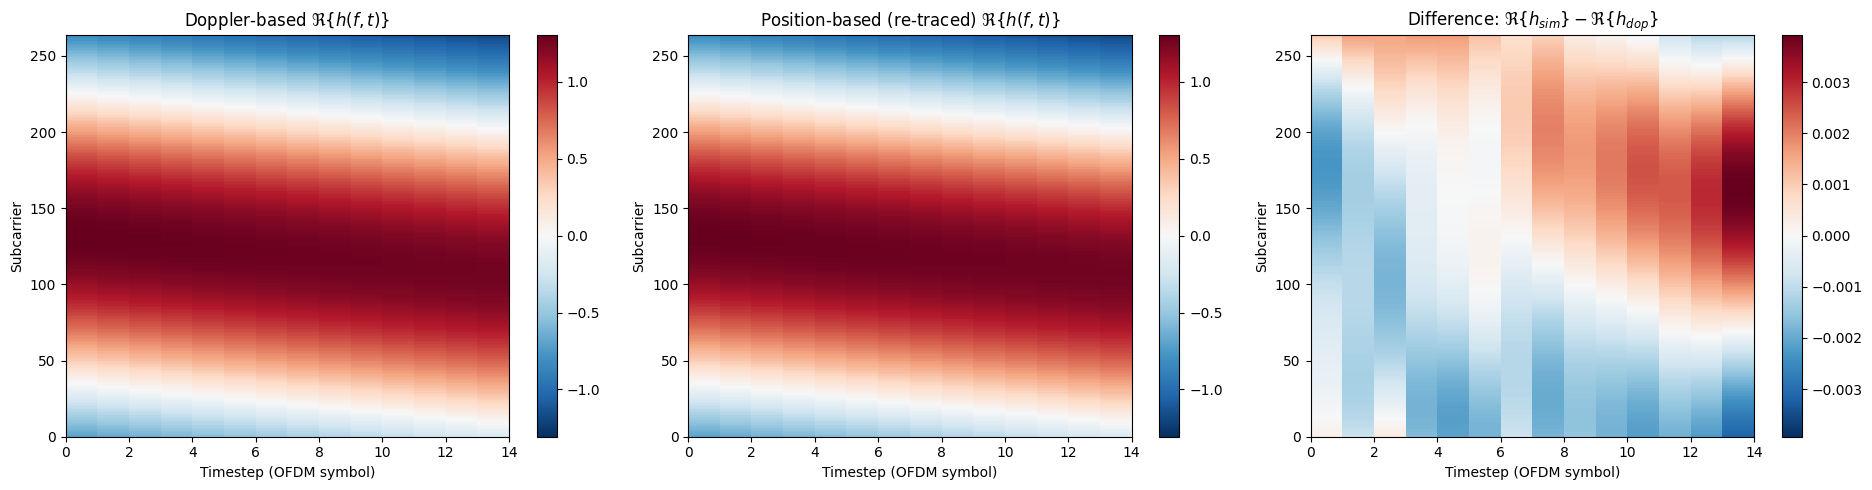

Relative L2 error between h_sim and h_dop (real part): 1.727e-03
=> 값이 충분히 작다면(예: <1e-2), 짧은 시간/거리 스케일에서는 Doppler 기반 근사가
   실제 재트레이싱과 잘 일치한다는 Mobility 튜토리얼의 결론을 재확인한 것입니다.


In [14]:
# ------------------------------------------------------------
# Timestep vs Re{h(f,t)} heatmap: h_dop vs h_sim 비교
# ------------------------------------------------------------
# Re{h}는 0을 중심으로 양/음을 오가므로, 부호가 잘 보이도록
# 0을 중심으로 대칭인 diverging colormap(vmin=-vmax)을 사용한다.
vmax = np.max(np.abs(np.real(np.concatenate([h_dop, h_sim], axis=0))))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

im0 = axes[0].pcolormesh(np.real(h_dop).T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
axes[0].set_title(r"Doppler-based $\Re\{h(f,t)\}$")
axes[0].set_xlabel("Timestep (OFDM symbol)")
axes[0].set_ylabel("Subcarrier")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(np.real(h_sim).T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
axes[1].set_title(r"Position-based (re-traced) $\Re\{h(f,t)\}$")
axes[1].set_xlabel("Timestep (OFDM symbol)")
axes[1].set_ylabel("Subcarrier")
fig.colorbar(im1, ax=axes[1])

diff = np.real(h_sim) - np.real(h_dop)
vmax_diff = max(np.max(np.abs(diff)), 1e-12)
im2 = axes[2].pcolormesh(diff.T, cmap="RdBu_r", vmin=-vmax_diff, vmax=vmax_diff, shading="auto")
axes[2].set_title(r"Difference: $\Re\{h_{sim}\} - \Re\{h_{dop}\}$")
axes[2].set_xlabel("Timestep (OFDM symbol)")
axes[2].set_ylabel("Subcarrier")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

rel_err = np.linalg.norm(diff) / np.linalg.norm(np.real(h_dop))
print(f"Relative L2 error between h_sim and h_dop (real part): {rel_err:.3e}")
print("=> 값이 충분히 작다면(예: <1e-2), 짧은 시간/거리 스케일에서는 Doppler 기반 근사가")
print("   실제 재트레이싱과 잘 일치한다는 Mobility 튜토리얼의 결론을 재확인한 것입니다.")
